# Notebook 04 — Interactive IIR precision exploration

The static notebooks in this series each walk through a specific
finding. This one is for **free exploration**: sliders and dropdowns
driving live plots of the filter, its quantized counterparts, and
the numerical-analysis metrics that quantify "will this design
survive this arithmetic".

Best viewed in JupyterLab or a VS Code notebook with the
`ipywidgets` extension enabled. On a plain `nbconvert` render you'll
see the static snapshot of each widget's default state; drop into a
live kernel to get the sliders.

### Contents

1. [Live filter designer](#1) — family / topology / order /
   cutoff → magnitude + phase + pole-zero
2. [Side-by-side two-type comparison](#2) — pick any two dtypes,
   see the overlay and the SQNR number
3. [Order sensitivity](#3) — slider over filter order, watch
   stability margin / condition number / pole displacement react
4. [Summary at a glance](#4) — SQNR heatmap + bar chart across all
   seven arithmetic configurations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

import mpdsp
from mpdsp.filters import compare_filters

print(f"mpdsp {mpdsp.__version__}  (sw::dsp {mpdsp.__dsp_version__})")
print(f"available dtypes: {mpdsp.available_dtypes()}")

# Filter family / topology registry — same shape used by the
# Streamlit dashboard in scripts/plot_dashboard.py but squeezed into
# the notebook directly so everything is self-contained.
ORDER_FAMILIES = {
    "Butterworth": {
        "lowpass":  mpdsp.butterworth_lowpass,
        "highpass": mpdsp.butterworth_highpass,
    },
    "Chebyshev I": {
        "lowpass":  lambda o, fs, fc: mpdsp.chebyshev1_lowpass(o, fs, fc, 0.5),
        "highpass": lambda o, fs, fc: mpdsp.chebyshev1_highpass(o, fs, fc, 0.5),
    },
    "Chebyshev II": {
        "lowpass":  lambda o, fs, fc: mpdsp.chebyshev2_lowpass(o, fs, fc, 40.0),
        "highpass": lambda o, fs, fc: mpdsp.chebyshev2_highpass(o, fs, fc, 40.0),
    },
    "Bessel": {
        "lowpass":  mpdsp.bessel_lowpass,
        "highpass": mpdsp.bessel_highpass,
    },
    "Legendre": {
        "lowpass":  mpdsp.legendre_lowpass,
        "highpass": mpdsp.legendre_highpass,
    },
    "Elliptic": {
        "lowpass":  lambda o, fs, fc: mpdsp.elliptic_lowpass(o, fs, fc, 0.5, 1.0),
        "highpass": lambda o, fs, fc: mpdsp.elliptic_highpass(o, fs, fc, 0.5, 1.0),
    },
}
FS = 44100.0
DTYPES = mpdsp.available_dtypes()

mpdsp 0.4.1.post2  (sw::dsp 0.4.1)
available dtypes: ['reference', 'gpu_baseline', 'ml_hw', 'posit_full', 'tiny_posit', 'cf24', 'half']


## 1. Live filter designer <a id='1'></a>

Move the sliders and watch the magnitude, phase, and pole-zero plot
react. The stability-margin value appears in the pole-zero subplot
title — watch it shrink as you push the order up or the cutoff down
(high-order low-cutoff filters cluster poles near the unit circle).

In [2]:
def _designer(family, topology, order, cutoff_hz):
    maker = ORDER_FAMILIES[family][topology]
    filt = maker(order, FS, cutoff_hz)

    freqs = np.linspace(0.0, 0.5, 1024)
    H = filt.frequency_response(freqs)
    mag_db = 20.0 * np.log10(np.maximum(np.abs(H), 1e-12))
    phase = np.unwrap(np.angle(H))

    fig, (ax_m, ax_p, ax_pz) = plt.subplots(1, 3, figsize=(15, 4))
    ax_m.plot(freqs * FS, mag_db, color="C0", linewidth=1.6)
    ax_m.set(xlabel="Freq (Hz)", ylabel="Mag (dB)", ylim=(-80, 5))
    ax_m.set_xscale("log")
    ax_m.grid(True, which="both", alpha=0.3)
    ax_m.set_title("Magnitude")

    ax_p.plot(freqs * FS, phase, color="C1", linewidth=1.6)
    ax_p.set(xlabel="Freq (Hz)", ylabel="Phase (rad)")
    ax_p.set_xscale("log")
    ax_p.grid(True, which="both", alpha=0.3)
    ax_p.set_title("Phase")

    theta = np.linspace(0, 2 * np.pi, 200)
    ax_pz.plot(np.cos(theta), np.sin(theta), color="0.6", linewidth=0.8)
    poles = np.asarray(filt.poles())
    ax_pz.scatter(poles.real, poles.imag, marker="x", s=80, color="C3", linewidths=2)
    ax_pz.set(aspect="equal", xlim=(-1.2, 1.2), ylim=(-1.2, 1.2),
              xlabel="Re(z)", ylabel="Im(z)",
              title=f"Poles (margin={filt.stability_margin():.4f})")
    ax_pz.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    _designer,
    family=widgets.Dropdown(options=list(ORDER_FAMILIES), value="Butterworth"),
    topology=widgets.Dropdown(options=["lowpass", "highpass"], value="lowpass"),
    order=widgets.IntSlider(min=1, max=8, step=1, value=4),
    cutoff_hz=widgets.FloatSlider(min=100.0, max=10_000.0, step=100.0, value=1000.0),
);

interactive(children=(Dropdown(description='family', options=('Butterworth', 'Chebyshev I', 'Chebyshev II', 'B…

## 2. Side-by-side two-type comparison <a id='2'></a>

Pick any two arithmetic configurations and see their impulse
responses overlaid, plus the SQNR and max-absolute-error between
them. The reference (`double`) SQNR against itself is always `inf`;
interesting comparisons are between any non-reference pair, or
between the reference and a quantized type.

In [3]:
def _compare_two(family, topology, order, cutoff_hz, dtype_a, dtype_b):
    maker = ORDER_FAMILIES[family][topology]
    filt = maker(order, FS, cutoff_hz)

    # Impulse response of length 256 — the interesting dynamics of most
    # IIR filters live in the first ~100 samples, so 256 gives a bit of
    # headroom without making the plot busy.
    impulse = np.zeros(256)
    impulse[0] = 1.0
    try:
        ya = filt.process(impulse, dtype=dtype_a)
        yb = filt.process(impulse, dtype=dtype_b)
    except Exception as e:
        print(f"process failed: {e}")
        return

    sqnr = mpdsp.sqnr_db(ya, yb) if np.any(ya != yb) else float("inf")
    max_abs = float(np.max(np.abs(ya - yb)))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ya, label=dtype_a, linewidth=2.2)
    ax.plot(yb, label=dtype_b, linewidth=1.2, linestyle="--")
    ax.set(xlabel="Sample", ylabel="Amplitude")
    ax.set_title(f"{family} / {topology}, order={order} @ {cutoff_hz:.0f} Hz  |  "
                 f"SQNR({dtype_a} vs {dtype_b}) = {sqnr:.1f} dB  |  "
                 f"max|Δ| = {max_abs:.2e}")
    ax.grid(True, alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(
    _compare_two,
    family=widgets.Dropdown(options=list(ORDER_FAMILIES), value="Chebyshev I"),
    topology=widgets.Dropdown(options=["lowpass", "highpass"], value="lowpass"),
    order=widgets.IntSlider(min=1, max=8, step=1, value=6),
    cutoff_hz=widgets.FloatSlider(min=100.0, max=10_000.0, step=100.0, value=1000.0),
    dtype_a=widgets.Dropdown(options=DTYPES, value="reference"),
    dtype_b=widgets.Dropdown(options=DTYPES, value="posit_full"),
);

interactive(children=(Dropdown(description='family', index=1, options=('Butterworth', 'Chebyshev I', 'Chebyshe…

## 3. Order sensitivity <a id='3'></a>

A fixed family + topology + cutoff — slide the order up and watch
the three numerical-analysis metrics react:

- **Stability margin** (1 - max|pole|) shrinks as poles push toward
  the unit circle.
- **Condition number** grows exponentially with order for high-Q
  families (Chebyshev I, Elliptic).
- **Pole displacement under `tiny_posit`** balloons once the design
  is close enough to the edge that 8-bit posit coefficients can no
  longer represent it faithfully.

In [4]:
def _order_sensitivity(family, topology, cutoff_hz, dtype_for_displacement):
    orders = list(range(1, 9))
    margin, cond, disp = [], [], []
    for o in orders:
        filt = ORDER_FAMILIES[family][topology](o, FS, cutoff_hz)
        margin.append(filt.stability_margin())
        cond.append(filt.condition_number())
        try:
            disp.append(filt.pole_displacement(dtype_for_displacement))
        except Exception:
            disp.append(float("nan"))

    fig, (ax_m, ax_c, ax_d) = plt.subplots(1, 3, figsize=(15, 4))
    ax_m.plot(orders, margin, "o-", color="C0")
    ax_m.set(xlabel="Order", ylabel="Stability margin", title="Stability")
    ax_m.set_yscale("log")
    ax_m.grid(True, which="both", alpha=0.3)

    ax_c.plot(orders, cond, "s-", color="C1")
    ax_c.set(xlabel="Order", ylabel="Condition number", title="Conditioning")
    ax_c.set_yscale("log")
    ax_c.grid(True, which="both", alpha=0.3)

    ax_d.plot(orders, disp, "^-", color="C2")
    ax_d.set(xlabel="Order", ylabel="Pole displacement",
             title=f"Displacement @ {dtype_for_displacement}")
    ax_d.set_yscale("log")
    ax_d.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    _order_sensitivity,
    family=widgets.Dropdown(options=list(ORDER_FAMILIES), value="Chebyshev I"),
    topology=widgets.Dropdown(options=["lowpass", "highpass"], value="lowpass"),
    cutoff_hz=widgets.FloatSlider(min=100.0, max=10_000.0, step=100.0, value=1000.0),
    dtype_for_displacement=widgets.Dropdown(options=[d for d in DTYPES if d != "reference"],
                                              value="tiny_posit"),
);

interactive(children=(Dropdown(description='family', index=1, options=('Butterworth', 'Chebyshev I', 'Chebyshe…

## 4. Summary at a glance <a id='4'></a>

Freezes on an order-6 / 1 kHz / 44.1 kHz design. SQNR heatmap over
all 6 classical families × all 7 arithmetic configs, plus the
grouped bar chart from the same data.

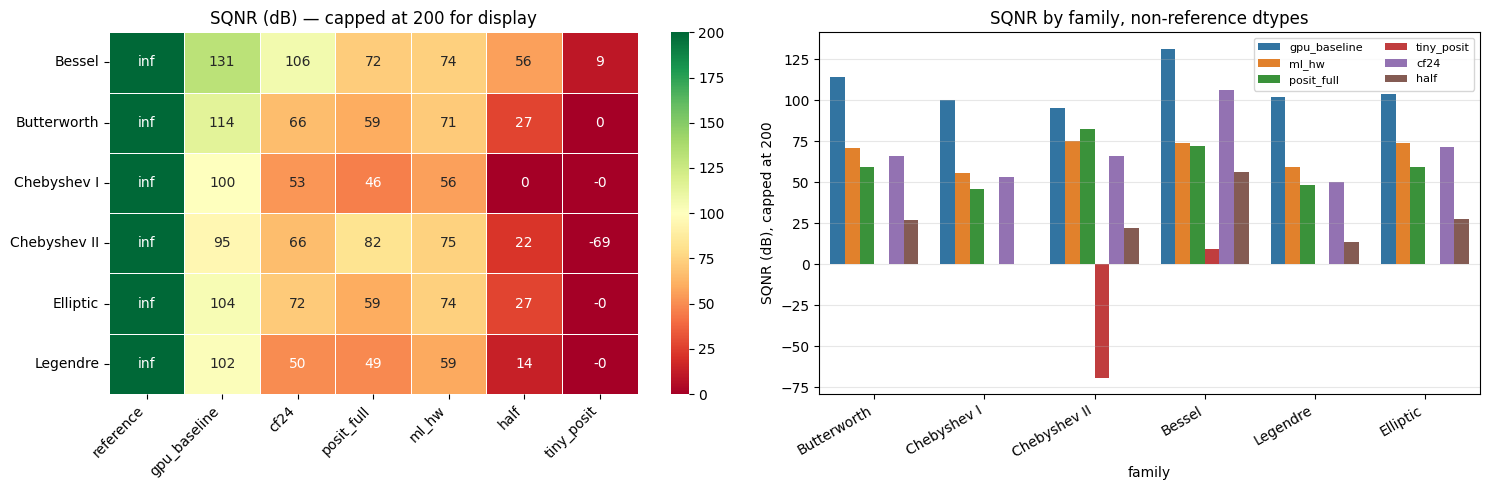

In [5]:
def _summary():
    order, cutoff = 6, 1000.0
    rows = []
    for family in ORDER_FAMILIES:
        filt = ORDER_FAMILIES[family]["lowpass"](order, FS, cutoff)
        signal = mpdsp.sine(length=2048, frequency=440.0, sample_rate=FS)
        for dt in DTYPES:
            try:
                out = filt.process(signal, dtype=dt)
                ref_out = filt.process(signal, dtype="reference")
                sqnr = mpdsp.sqnr_db(ref_out, out)
            except Exception:
                sqnr = float("nan")
            rows.append({"family": family, "dtype": dt, "sqnr_db": sqnr})
    df = pd.DataFrame(rows)
    pivot = df.pivot_table(index="family", columns="dtype", values="sqnr_db")

    # Order columns from wide to narrow for readability.
    ordered = [d for d in ["reference", "gpu_baseline", "cf24", "posit_full",
                           "ml_hw", "half", "tiny_posit"] if d in pivot.columns]
    pivot = pivot[ordered]

    fig, (ax_hm, ax_bar) = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(pivot.clip(upper=200), annot=pivot.map(
                    lambda v: "inf" if v >= 290 else f"{v:.0f}").to_numpy(),
                fmt="", cmap="RdYlGn", vmin=0, vmax=200, ax=ax_hm,
                linewidths=0.5, linecolor="white")
    ax_hm.set_title("SQNR (dB) — capped at 200 for display")
    ax_hm.set_xlabel("")
    ax_hm.set_ylabel("")
    plt.setp(ax_hm.get_xticklabels(), rotation=45, ha="right")

    # Bar chart: non-reference dtypes only.
    plot_df = df[df["dtype"] != "reference"].copy()
    plot_df["sqnr_db"] = plot_df["sqnr_db"].clip(upper=200)
    sns.barplot(data=plot_df, x="family", y="sqnr_db", hue="dtype", ax=ax_bar)
    ax_bar.set_title("SQNR by family, non-reference dtypes")
    ax_bar.set_ylabel("SQNR (dB), capped at 200")
    ax_bar.legend(fontsize=8, loc="upper right", ncol=2)
    ax_bar.grid(True, alpha=0.3, axis="y")
    plt.setp(ax_bar.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

_summary()

---

Next steps:

- For filter-design work you want to re-open the notebook on, use
  **JupyterLab** or **VS Code** — the widgets in §1-§3 only wire up
  when there's a live kernel driving them.
- For a richer interactive experience with export buttons, try the
  Streamlit dashboard at `scripts/plot_dashboard.py`
  (`streamlit run scripts/plot_dashboard.py`).
- For the numerical-analysis deep dive, see notebook
  `09_numerical_analysis.ipynb`.